### 📦 INSTALL LIBRARIES AND CONFIGS

In [ ]:
!pip install -q scikit-learn pandas matplotlib seaborn kneed gspread gspread_dataframe

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

from kneed import KneeLocator

import warnings
import gspread
from google.colab import drive
from gspread_dataframe import set_with_dataframe
from google.colab import auth
from google.auth import default

# Configs:
warnings.filterwarnings('ignore')
drive.mount('/content/drive')

# Google Authetication:
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 📂 LOAD DATA

In [ ]:
file_path = '/content/drive/My Drive/Trí tuệ kinh doanh (CO5235) - Group 8/Nam/Zomato Dataset.csv'
df = pd.read_csv(file_path)

# Get information about data:
df.info()

# Calculate the numbers of null values:
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731


### 🧹 CLEAN DATA

In [ ]:
# Fill missing numerical values with the mean and categorical values with the mode:
for column in df.select_dtypes(include=[np.number]).columns:
    df[column].fillna(df[column].mean(), inplace=True)
for column in df.select_dtypes(include=[object]).columns:
    df[column].fillna(df[column].mode()[0], inplace=True)
df.isnull().sum()

# Converting 'Order_Date' to datetime:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df.info()

# Fill missing dates with the median date:
median_date = df['Order_Date'].median()
df['Order_Date'].fillna(median_date, inplace=True)

# Converting numerical columns to appropriate types:
numerical_columns = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude',
                     'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries', 'Time_taken (min)']
for column in numerical_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')
df.info()

# Check for duplicates
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           45584 non-null  object        
 1   Delivery_person_ID           45584 non-null  object        
 2   Delivery_person_Age          45584 non-null  float64       
 3   Delivery_person_Ratings      45584 non-null  float64       
 4   Restaurant_latitude          45584 non-null  float64       
 5   Restaurant_longitude         45584 non-null  float64       
 6   Delivery_location_latitude   45584 non-null  float64       
 7   Delivery_location_longitude  45584 non-null  float64       
 8   Order_Date                   21001 non-null  datetime64[ns]
 9   Time_Orderd                  45584 non-null  object        
 10  Time_Order_picked            45584 non-null  object        
 11  Weather_conditions           45584 non-nu

np.int64(0)

### 🛠️ DRIVER‑LEVEL FEATURES

In [ ]:
driver_df = (df.groupby('Delivery_person_ID')
               .agg(
                  avg_time_min      = ('Time_taken (min)', 'mean'),
                  orders_cnt        = ('ID', 'count'),
                  rating_mean       = ('Delivery_person_Ratings', 'mean'),
                )
               .reset_index())
print('Numbers of drivers:', len(driver_df))
driver_df.head()

Numbers of drivers: 1320


,Delivery_person_ID,avg_time_min,orders_cnt,rating_mean
0,AGRRES010DEL01,24.500000,14,4.752412
1,AGRRES010DEL02,28.800000,15,4.668918
2,AGRRES010DEL03,27.615385,13,4.600000
3,AGRRES01DEL01,26.833333,12,4.550110
4,AGRRES01DEL02,24.428571,14,4.700000


### 📏 SCALE + CHOOSE K

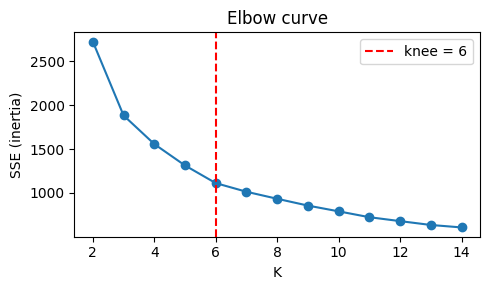

Chosen K = 6


In [ ]:
features = [
  'avg_time_min',
  'orders_cnt',
  'rating_mean',
]

X = driver_df[features].fillna(driver_df[features].median())
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Elbow curve
Ks, inertias = [], []
for k in range(2, 15):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    Ks.append(k); inertias.append(km.inertia_)

# Knee detection
knee = KneeLocator(Ks, inertias, curve='convex', direction='decreasing')
BEST_K = knee.elbow

plt.figure(figsize=(5,3))
plt.plot(Ks, inertias, marker='o')
plt.axvline(BEST_K, ls='--', c='red', label=f'knee = {BEST_K}')
plt.xlabel('K'); plt.ylabel('SSE (inertia)')
plt.title('Elbow curve')
plt.legend(); plt.tight_layout(); plt.show()

print('Chosen K =', BEST_K)

### 🚀 FIT FINAL MODEL

In [ ]:
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
driver_df['cluster'] = km_final.fit_predict(Xs)

cluster_sizes = driver_df['cluster'].value_counts().sort_index()
print('Cluster sizes:\n', cluster_sizes)

Cluster sizes:
 cluster
0    380
1    108
2    177
3    332
4    161
5    162
Name: count, dtype: int64


### 📊 VISUALISE (PCA 2‑D scatter)

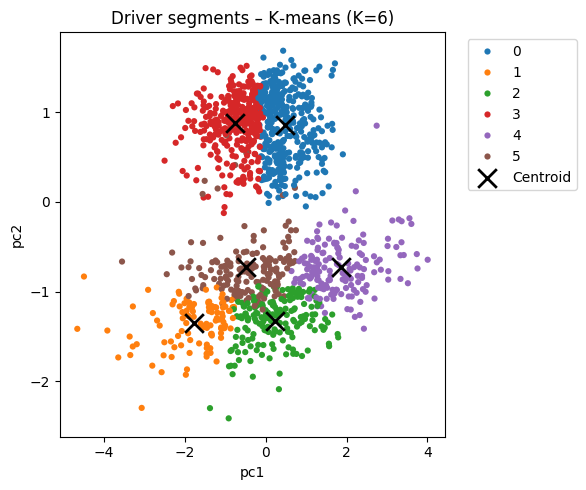

avg_time_min        orders_cnt        rating_mean       
                mean median       mean median        mean median
cluster                                                         
0              25.40  25.46      51.42   54.0        4.66   4.66
1              29.59  29.23      12.32   12.0        4.57   4.58
2              27.79  27.54      11.88   12.0        4.70   4.69
3              27.16  27.11      55.70   57.0        4.60   4.61
4              23.69  24.08      12.10   12.0        4.71   4.71
5              25.82  26.00      13.40   13.0        4.56   4.57

Silhouette_avg = 0.323  |  Davies‑Bouldin = 0.997


In [ ]:
pca = PCA(n_components=2).fit_transform(Xs)
driver_df['pc1'] = pca[:,0]; driver_df['pc2'] = pca[:,1]

centroids_pc = (driver_df
                .groupby('cluster')[['pc1','pc2']]
                .mean()
                .reset_index())

plt.figure(figsize=(6,5))
sns.scatterplot(data=driver_df, x='pc1', y='pc2',
                hue='cluster', palette='tab10', s=20, linewidth=0)

plt.scatter(centroids_pc['pc1'], centroids_pc['pc2'],
            marker='x', s=180, c='black', linewidths=2,
            label='Centroid')

plt.title(f'Driver segments – K‑means (K={BEST_K})')
plt.legend(bbox_to_anchor=(1.04,1), loc='upper left')
plt.tight_layout(); plt.show()

# Summary stats per cluster
summary = (driver_df.groupby('cluster')[features]
           .agg(['mean','median'])
           .round(2))
display(summary)

sil = silhouette_score(Xs, driver_df['cluster'])
dbi = davies_bouldin_score(Xs, driver_df['cluster'])
print(f'Silhouette_avg = {sil:.3f}  |  Davies‑Bouldin = {dbi:.3f}')

### 💾 SAVE TO GOOGLE SHEET

In [ ]:
# Create new Sheet of Google Sheet:
spreadsheet = gc.create("ClusteredDrivers")
worksheet = spreadsheet.sheet1

# Write the result data to Sheet:
set_with_dataframe(worksheet, driver_df)
print("✅ Data written to Google Sheet:")
print(spreadsheet.url)

✅ Data written to Google Sheet:
https://docs.google.com/spreadsheets/d/1t2I47-0bhu5E52KUOP26MfZeA8yU15jvvPv7BV5Khgo
